<a href="https://colab.research.google.com/github/carolcalandrine/Analise-churn/blob/main/projeto_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Churn

Churn refere-se ao momento em que um cliente deixa de utilizar os serviços ou produtos de uma empresa. Esse é um dos principais desafios enfrentados por organizações, especialmente em setores como telecomunicações, bancos e serviços por assinatura, pois a perda de clientes impacta diretamente na receita e no crescimento do negócio.

Dessa forma, compreender os fatores que levam um cliente a cancelar um serviço é essencial para a criação de estratégias de retenção mais eficientes.

## Objetivo do estudo
Realizar uma análise exploratória dos dados

In [40]:
#importação de bibliotecas
import pandas as pd #manipular tabelas
import numpy as np #operações
import seaborn as sb #manipular gráficos
import matplotlib.pyplot as plt #manipular gráficos

In [49]:
# Importação do arquivo .csv
df = pd.read_csv('/content/customer_churn_with_months.csv')

## Dicionário das variáveis

- `customerID`:
- `Tipo de empresa`:
- `Fundação da empresa`:
- `Possui mais de sócio`:
- `Funcionários`:
- `Meses de permanência`:
- `Utiliza serviços financeiros`:
- `PossuiContador`:
- `Faz conciliação bancária`:
- `Módulo financeiro`:
- `Relatórios`:
- `Utilização de APIs de integração`:
- `Contrato`:
- `Emite boletos`:
- `Emite boletos.1`:
- `Tipo de pagamento`:
- `Receita mensal`:
- `Receita total`:
- `Churn`:
- `mes_churn`:   

## Análise Exploratória dos Dados

### Exploração Univariada

In [6]:
df.head() #Ver as 5 primeiras linhas da tabela

,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
0,1,Micro empresa,2016,Sim,até 5 funcionários,1,Não,NaN,automática,Pouco uso,...,Pouco uso,Pouco uso,Mês-a-mês,1,Yes,Boleto - pagamento único,29.85,29.85,Não,NaN
1,2,Pequena empresa,2018,Não,até 5 funcionários,34,Sim,Não,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Boleto - mês a mês,56.95,1889.50,Não,NaN
2,4,Pequena empresa,2016,Não,até 5 funcionários,45,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Cartão de crédito - pagamento único,42.30,1840.75,Não,NaN
3,7,Pequena empresa,2019,Não,6 ou mais funcionários,22,Sim,Sim,manual,Pouco uso,...,Uso frequente,Pouco uso,Mês-a-mês,1,Yes,Cartão de crédito - mês a mês,89.10,1949.40,Não,NaN
4,8,Micro empresa,2019,Não,até 5 funcionários,10,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Mês-a-mês,0,No,Boleto - mês a mês,29.75,301.90,Não,NaN


In [7]:
# Overview da tabela
overview = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum().round(2),
    '% Nulos': (df.isnull().mean() * 100).round(2),
    'Valores únicos': df.nunique(),
    'Exemplo de valores': df.apply(lambda x: x.unique()[:3])
})
overview

,Tipo,Nulos,% Nulos,Valores únicos,Exemplo de valores
ID,int64,0,0.00,7043,"[1, 2, 4]"
Tipo de empresa,object,0,0.00,2,"[Micro empresa, Pequena empresa]"
Fundação da empresa,int64,0,0.00,21,"[2016, 2018, 2019]"
Possui mais de um sócio,object,0,0.00,2,"[Sim, Não]"
Funcionários,object,0,0.00,2,"[até 5 funcionários, 6 ou mais funcionários]"
Meses de permanência,int64,0,0.00,73,"[1, 34, 45]"
Utiliza serviços financeiros,object,0,0.00,2,"[Não, Sim]"
PossuiContador,object,682,9.68,2,"[nan, Não , Sim]"
Faz conciliação bancária,object,0,0.00,3,"[automática, manual, não faz]"
Frequência de utilização de feature do sistema: Módulo financeiro,object,0,0.00,3,"[Pouco uso, Uso frequente, Nunca utilizou]"


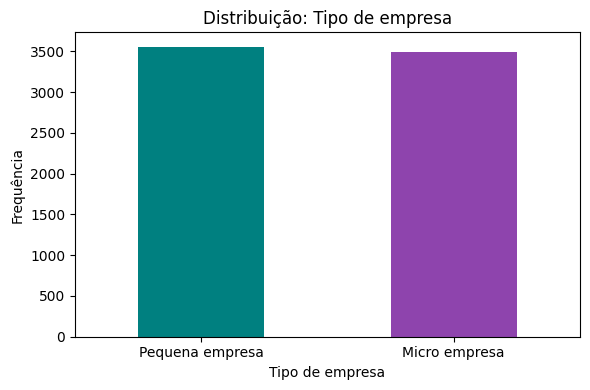

(Tipo de empresa
 Pequena empresa    3555
 Micro empresa      3488
 Name: count, dtype: int64,
 Tipo de empresa
 Pequena empresa    50.48
 Micro empresa      49.52
 Name: proportion, dtype: float64,
 array(['Micro empresa', 'Pequena empresa'], dtype=object))

In [54]:
# Análise da coluna 'Tipo de empresa'

col = 'Tipo de empresa' #col é o nome da coluna (variável)

# Valores únicos
valores_unicos = df[col].unique()  #Pegue a coluna Idade, encontre os valores únicos dela e guarde isso na variável valores_unicos

# Frequência Absoluta e Relativa
freq_abs = df[col].value_counts()
freq_rel = round(df[col].value_counts(normalize=True)* 100,2)

# Visualização
plt.figure(figsize=(6,4)) #Define o tamanho da imagem
freq_abs.plot(kind='bar', color=['#008080','#8e44ad']) #kind=bar é o tipo de gráfico, color= cor do gráfico
plt.title('Distribuição: Tipo de empresa') #titulo
plt.xlabel('Tipo de empresa') #nome dos eixos
plt.ylabel('Frequência')
plt.xticks(rotation=0) # rotação
plt.tight_layout() #Ajusta o layout
plt.show()

freq_abs, freq_rel, valores_unicos #retorna os resultados

A variável 'Tipo de empresa' é do tipo categórica, e não apresenta valores ausentes ou inconsistentes.
A distribuição mostra que não há uma predominância de um grupo, mas que há um equilíbrio entre as duas variáveis com 50,47% para Pequena empresa e 49,52% para Micro empresa.
Isso pode indicar que existe uma amostragem balanceada e do ponto de vista analítico, essa variável pode ser explorada em análises relacionadas ao churn.

Valores únicos: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Mínimo: 2001
Máximo: 2021
Média: 2016.74
Mediana: 2018.0
Desvio padrão: 4.58
Top 5 anos de fundação:
Fundação da empresa
2016    1029
2018     990
2019     982
2021     975
2017     969
Name: count, dtype: int64


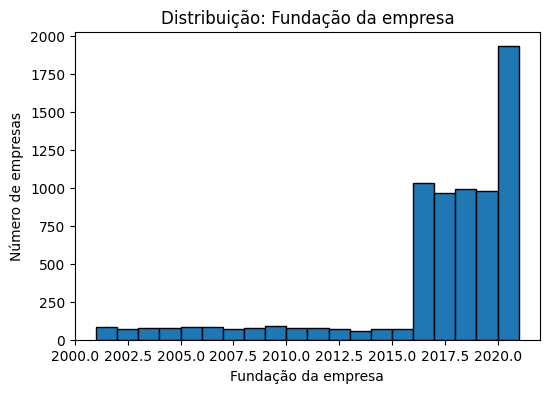

In [50]:
## Análise da coluna 'Fundação da empresa'
col = 'Fundação da empresa'  #Extraindo a coluna do DataFrame
anos = df[col]

#Valores unicos
print('Valores únicos:', sorted(df[col].unique().tolist())) #unique: valores únicos, tolist: transforma em lista, sorted: ordem crescente

# Estatística descritiva
print('Mínimo:', anos.min())
print('Máximo:', anos.max())
print('Média:', round(anos.mean(), 2))
print('Mediana:', anos.median())
print('Desvio padrão:', round(anos.std(),2)) #Calcular desvio padrão

#Frequência dos anos mais comuns
top_anos = anos.value_counts().head()
print('Top 5 anos de fundação:')
print(top_anos)

#Histograma
plt.figure(figsize=(6,4))
plt.hist(anos, bins=20, edgecolor='black')
plt.title('Distribuição: Fundação da empresa')
plt.xlabel('Fundação da empresa')
plt.ylabel('Número de empresas')
plt.show()


Variável qualitativa (categórica) ordinal

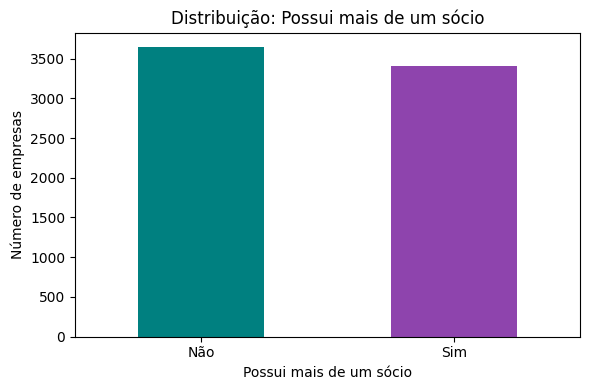

(array(['Sim', 'Não'], dtype=object),
 Possui mais de um sócio
 Não    3641
 Sim    3402
 Name: count, dtype: int64,
 Possui mais de um sócio
 Não    51.69672
 Sim    48.30328
 Name: proportion, dtype: float64)

In [53]:
# Análise da coluna 'Possui mais de um sócio'

col = 'Possui mais de um sócio'

# Valores únicos
valores_unicos = df[col].unique()

# Frequência Relativa e Absoluta
freq_abs = df[col].value_counts()
freq_rel = df[col].value_counts(normalize=True) * 100

# Visualização
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribuição: Possui mais de um sócio')
plt.xlabel('Possui mais de um sócio')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

valores_unicos, freq_abs, freq_rel

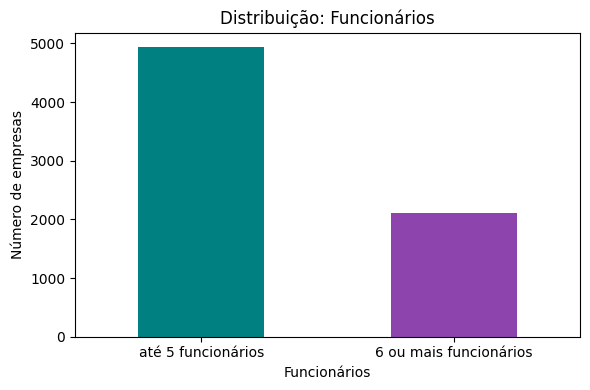

In [52]:
# Análise da variável 'Funcionários'
col = 'Funcionários'

#Valores únicos
valores_unicos = df[col].unique()

# Frequência absoluta e relativa
freq_abs = df[col].value_counts()
freq_rel = df[col].value_counts(normalize=True) * 100

# Visualização
plt.figure(figsize=(6,4))
freq_abs.plot(kind='bar', color=['#008080','#8e44ad'])
plt.title('Distribuição: Funcionários')
plt.xlabel('Funcionários')
plt.ylabel('Número de empresas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

